# 03 — Unsupervised Learning: Clustering & Visualization
**Owner:** team · **Status:** after 01 / aligned with notebooks/02_classifiers.ipynb

## What this notebook does
- Loads train/val/test from `data/processed/`
- Same text cleaning as notebook 02
- TF-IDF: fit on train `cleaned_text` only; transform val & test (same vocabulary)
- Truncated SVD (LSA): fit on train TF-IDF only; transform val & test → `Z_train`, `Z_val`, `Z_test` for clustering / t-SNE
- Optional Ekman multi-label arrays `y_*` for later metrics (ARI/NMI), not for fitting unsupervised steps

## Input files (pull from repo)
- `data/processed/train.csv`, `val.csv`, `test.csv`

## Figures (after clustering cells are added)
- `report/figures/tsne_clusters.png`, `report/figures/tsne_true_labels.png`

## How to run
Run from **`notebooks/`**. Top-to-bottom. t-SNE is slow — subsample (~5000 rows) later.

In [12]:
# Import libraries
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLTK resources (run once)
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Load splits from data/processed (run notebook from notebooks/ so ROOT resolves like 01_data_prep)
ROOT = Path("..")
PROCESSED_DIR = ROOT / "data" / "processed"

train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

print(f"Loaded CSVs from {PROCESSED_DIR.resolve()}")
print(f"train: {train_df.shape} | val: {val_df.shape} | test: {test_df.shape}")


Loaded CSVs from /Users/Zhuanz/Documents/GitHub/EmotionRadar/data/processed
train: (43410, 8) | val: (5426, 8) | test: (5427, 8)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/Zhuanz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/Zhuanz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/Zhuanz/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [13]:
# ----------------------
# Text Preprocessing
# ----------------------
# Initialize tools
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove URLs (Reddit links)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    # 3. Remove special characters, numbers, and extra spaces
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    # 4. Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]

    # drop profane tokens
    # -------------DISSCUSSION-------------
    # maybe we shouldn't filter out profanity, because it represent some emotions like anger，disappointment
    # tokens = [t for t in tokens if not profanity.contains_profanity(t)]
    # -------------DISSCUSSION-------------

    # 5. Join tokens back to text
    return " ".join(tokens)


for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["cleaned_text"] = df["text"].apply(preprocess_text)

print("Preprocessing done for train, val, test.")
print(f"  train: {len(train_df)} rows | val: {len(val_df)} rows | test: {len(test_df)} rows")

label_cols = [c for c in train_df.columns if c not in ("text", "cleaned_text")]
print("\nSample (train):")
print(train_df[["text", "cleaned_text"] + label_cols].head(3))


Preprocessing done for train, val, test.
  train: 43410 rows | val: 5426 rows | test: 5427 rows

Sample (train):
                                                text  \
0  My favourite food is anything I didn't have to...   
1  Now if he does off himself, everyone will thin...   
2                     WHY THE FUCK IS BAYLESS ISOING   

                                        cleaned_text  anger  disgust  fear  \
0                 favourite food anything didnt cook      0        0     0   
1  everyone think he laugh screwing people instea...      0        0     0   
2                                fuck bayless isoing      1        0     0   

   joy  sadness  surprise  neutral  
0    0        0         0        1  
1    0        0         0        1  
2    0        0         0        0  


In [14]:
# ----------------------
# TF-IDF Vectorization
# ----------------------
# Fit on train only; transform val/test with the same vocabulary (no leakage).
label_cols = [c for c in train_df.columns if c not in ("text", "cleaned_text")]

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
)

X_train = tfidf_vectorizer.fit_transform(train_df["cleaned_text"])
X_val = tfidf_vectorizer.transform(val_df["cleaned_text"])
X_test = tfidf_vectorizer.transform(test_df["cleaned_text"])

y_train = train_df[label_cols].to_numpy()
y_val = val_df[label_cols].to_numpy()
y_test = test_df[label_cols].to_numpy()

print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"X_train: {X_train.shape} (sparse) | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} (sparse) | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape} (sparse) | y_test:  {y_test.shape}")
print(f"Labels ({len(label_cols)}): {label_cols}")


Vocabulary size: 5000
X_train: (43410, 5000) (sparse) | y_train: (43410, 7)
X_val:   (5426, 5000) (sparse) | y_val:   (5426, 7)
X_test:  (5427, 5000) (sparse) | y_test:  (5427, 7)
Labels (7): ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']


  (plot) 50% variance: not reached within k=500 (max cumulative = 48.93%)


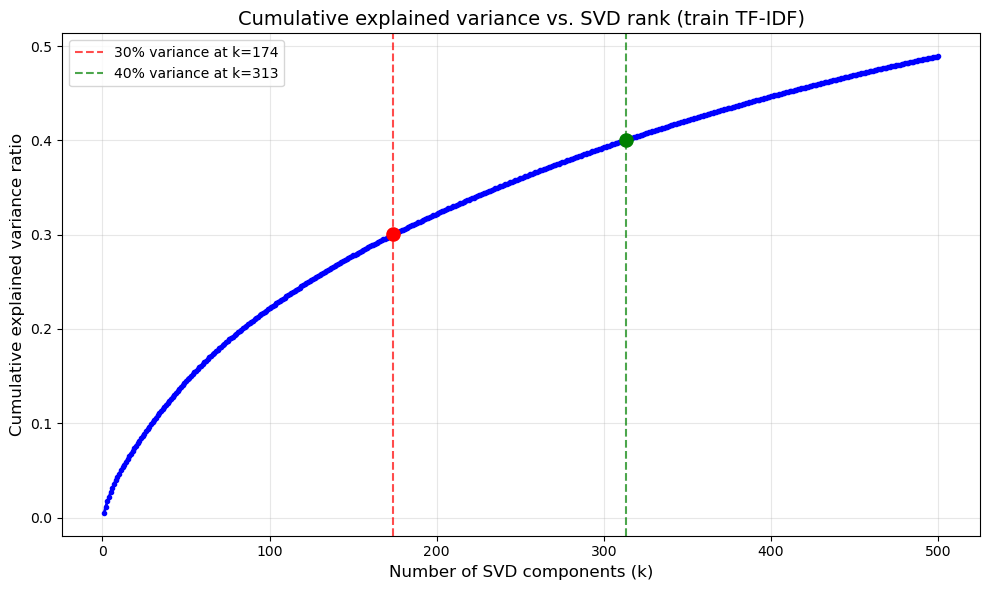


=== Dimension hints (train only) ===
  - 30% variance: k = 174
  - 40% variance: k = 313
  - 50% variance: not reached within k=500

Cumulative variance at k=100: 22.21%

Chosen n_components=174 (smallest k with ≥30% train variance; rank cap=4999).


In [15]:
# ----------------------
# Truncated SVD — variance curve 
# ----------------------
# Fit a high-rank SVD on X_train only (diagnostic curve; same split discipline as notebook 02).


def smallest_k_at_least_variance(cumulative, thresh):
    """Return smallest k such that cumulative[k-1] >= thresh, or None if never reached."""
    for idx, var in enumerate(cumulative):
        if var >= thresh:
            return idx + 1
    return None


max_rank = min(500, X_train.shape[0] - 1, X_train.shape[1] - 1)
svd_for_analysis = TruncatedSVD(n_components=max_rank, random_state=42)
svd_for_analysis.fit(X_train)

cumulative_variance = svd_for_analysis.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    linestyle="-",
    color="b",
    linewidth=2,
    markersize=3,
)

thresholds = [0.30, 0.40, 0.50]
colors = ["r", "g", "orange"]
labels_thresh = ["30% variance", "40% variance", "50% variance"]

for thresh, color, lbl in zip(thresholds, colors, labels_thresh):
    dim = smallest_k_at_least_variance(cumulative_variance, thresh)
    if dim is None:
        print(
            f"  (plot) {lbl}: not reached within k={max_rank} "
            f"(max cumulative = {cumulative_variance[-1]:.2%})"
        )
        continue
    plt.axvline(x=dim, color=color, linestyle="--", alpha=0.7, label=f"{lbl} at k={dim}")
    plt.scatter(dim, cumulative_variance[dim - 1], color=color, s=90, zorder=5)

plt.title("Cumulative explained variance vs. SVD rank (train TF-IDF)", fontsize=14)
plt.xlabel("Number of SVD components (k)", fontsize=12)
plt.ylabel("Cumulative explained variance ratio", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\n=== Dimension hints (train only) ===")
for thresh, lbl in zip(thresholds, labels_thresh):
    dim = smallest_k_at_least_variance(cumulative_variance, thresh)
    if dim is None:
        print(f"  - {lbl}: not reached within k={max_rank}")
    else:
        print(f"  - {lbl}: k = {dim}")
if len(cumulative_variance) >= 100:
    print(f"\nCumulative variance at k=100: {cumulative_variance[99]:.2%}")

# Choose k for embeddings: aim for ≥30% on train (fallback = max_rank cap if unreachable)
# n_svd_components
var_target = 0.30
n_svd_max = min(X_train.shape[0] - 1, X_train.shape[1] - 1)
k_for_target = smallest_k_at_least_variance(cumulative_variance, var_target)
if k_for_target is None:
    n_svd_components = int(min(max_rank, n_svd_max))
    print(
        f"\nChosen n_components={n_svd_components} "
        f"({var_target:.0%} variance not reached in k≤{max_rank}; using analysis cap)."
    )
else:
    n_svd_components = int(min(k_for_target, n_svd_max))
    print(
        f"\nChosen n_components={n_svd_components} "
        f"(smallest k with ≥{var_target:.0%} train variance; rank cap={n_svd_max})."
    )


In [16]:
# ----------------------
# Truncated SVD — embeddings for clustering / t-SNE
# ----------------------
# Fit SVD rank on train only; transform val and test with the same subspace.

svd_embedder = TruncatedSVD(n_components=n_svd_components, random_state=42)

Z_train = svd_embedder.fit_transform(X_train)
Z_val = svd_embedder.transform(X_val)
Z_test = svd_embedder.transform(X_test)

explained_total = float(svd_embedder.explained_variance_ratio_.sum())
print("\nLSA embeddings (dense)")
print(f"  Z_train: {Z_train.shape} | Z_val: {Z_val.shape} | Z_test: {Z_test.shape}")
print(f"Variance explained by these {n_svd_components} components (train): ~{explained_total:.2%}")
print("\nDone — ready for k-means / t-SNE downstream.")



LSA embeddings (dense)
  Z_train: (43410, 174) | Z_val: (5426, 174) | Z_test: (5427, 174)
Variance explained by these 174 components (train): ~29.84%

Done — ready for k-means / t-SNE downstream.


<!-- clustering-section-generated -->
## Clustering and t-SNE

This section uses the SVD/LSA embeddings from above (`Z_train`) for unsupervised clustering. The Ekman labels are used only after clustering, to describe how well the clusters line up with known emotion categories.


In [17]:
# ----------------------
# Clustering setup
# ----------------------
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import normalize

FIGURE_DIR = ROOT / "report" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_CLUSTERS = len(label_cols)


# We use normalized SVD embeddings for K-means because K-means is distance-based.
# Normalization makes text vectors more comparable.
Z_train_norm = normalize(Z_train)
Z_val_norm = normalize(Z_val)
Z_test_norm = normalize(Z_test)


def dominant_label_from_multilabel(y, labels):
    """Convert multi-label binary rows into one label for plots/ARI/NMI diagnostics."""
    y = np.asarray(y)
    has_label = y.sum(axis=1) > 0
    dominant_idx = y.argmax(axis=1)
    dominant = np.array(labels, dtype=object)[dominant_idx]
    dominant[~has_label] = "none"
    return dominant


y_train_dominant = dominant_label_from_multilabel(y_train, label_cols)
y_val_dominant = dominant_label_from_multilabel(y_val, label_cols)
y_test_dominant = dominant_label_from_multilabel(y_test, label_cols)

print(f"Figure output directory: {FIGURE_DIR.resolve()}")
print("Dominant train-label distribution:")
print(pd.Series(y_train_dominant).value_counts())


Figure output directory: /Users/Zhuanz/Documents/GitHub/EmotionRadar/report/figures
Dominant train-label distribution:
joy         16920
neutral     12823
anger        5579
surprise     4160
sadness      2599
fear          691
disgust       638
Name: count, dtype: int64


Rows available for clustering: 42512 / 43410
Filtered zero-vector rows: 898


,k,inertia,silhouette
0,2,4802.371001,0.011941
1,3,4722.996547,0.020474
2,4,4667.760685,0.025074
3,5,4618.586835,0.029461
4,6,4575.196950,0.033002
5,7,4528.527614,0.038090
6,8,4492.666453,0.040879
7,9,4449.053752,0.043468
8,10,4425.083433,0.046154
9,11,4378.716252,0.049337


Auto-selected k=14 based on highest silhouette score (0.0579).
Chosen k=7 for final clustering because the project uses 7 Ekman emotion categories. We use the automatic silhouette result as a diagnostic, not as the only decision rule.


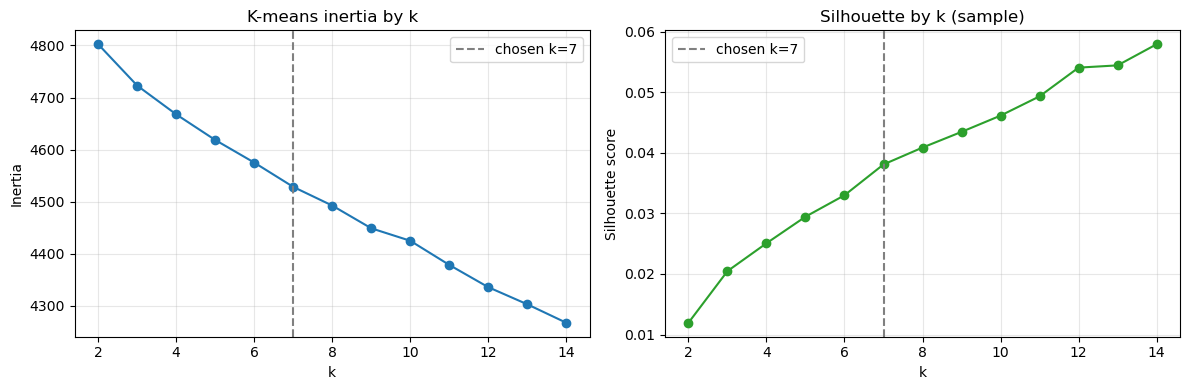

Saved k-selection figure to ../report/figures/kmeans_model_selection.png


In [18]:
# ----------------------
# Optional k-selection diagnostic
# ----------------------
# Silhouette is expensive on 43k rows, so estimate it on a reproducible subsample.
# We use normalized SVD embeddings from the previous setup cell.
# We also remove zero TF-IDF rows because they contain no useful lexical signal.

nonzero_train_mask = X_train.getnnz(axis=1) > 0

Z_for_k_selection = Z_train_norm[nonzero_train_mask]
train_cluster_df = train_df.loc[nonzero_train_mask].reset_index(drop=True).copy()
y_train_dominant_cluster = y_train_dominant[nonzero_train_mask]

print(f"Rows available for clustering: {Z_for_k_selection.shape[0]} / {Z_train_norm.shape[0]}")
print(f"Filtered zero-vector rows: {(~nonzero_train_mask).sum()}")

model_selection_sample_size = min(5000, Z_for_k_selection.shape[0])

rng = np.random.default_rng(RANDOM_STATE)
model_selection_idx = rng.choice(
    Z_for_k_selection.shape[0],
    size=model_selection_sample_size,
    replace=False
)

Z_model_selection = Z_for_k_selection[model_selection_idx]

k_values = range(2, 15)
model_selection_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    sample_clusters = km.fit_predict(Z_model_selection)
    
    model_selection_rows.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(Z_model_selection, sample_clusters),
        }
    )

k_selection_df = pd.DataFrame(model_selection_rows)
display(k_selection_df)

# Automatic result based only on silhouette
auto_best_k_row = k_selection_df.loc[k_selection_df["silhouette"].idxmax()]
auto_best_k = int(auto_best_k_row["k"])

print(
    f"Auto-selected k={auto_best_k} based on highest silhouette score "
    f"({auto_best_k_row['silhouette']:.4f})."
)

# Final chosen k for the project
# Change this after looking at elbow curve + silhouette + interpretability.
chosen_k = N_CLUSTERS

print(
    f"Chosen k={chosen_k} for final clustering because the project uses "
    f"{N_CLUSTERS} Ekman emotion categories. We use the automatic silhouette result "
    f"as a diagnostic, not as the only decision rule."
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_selection_df["k"], k_selection_df["inertia"], marker="o")
axes[0].axvline(chosen_k, linestyle="--", color="gray", label=f"chosen k={chosen_k}")
axes[0].set_title("K-means inertia by k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(k_selection_df["k"], k_selection_df["silhouette"], marker="o", color="tab:green")
axes[1].axvline(chosen_k, linestyle="--", color="gray", label=f"chosen k={chosen_k}")
axes[1].set_title("Silhouette by k (sample)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
k_selection_path = FIGURE_DIR / "kmeans_model_selection.png"
plt.savefig(k_selection_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved k-selection figure to {k_selection_path}")

In [19]:
# ----------------------
# Final k-means model: k = 7 Ekman categories
# ----------------------
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE)
train_clusters = kmeans.fit_predict(Z_train_norm)
val_clusters = kmeans.predict(Z_val_norm)
test_clusters = kmeans.predict(Z_test_norm)

# Evaluate against dominant labels only as a diagnostic. Clustering was not fit with labels.
train_silhouette = silhouette_score(Z_model_selection, kmeans.predict(Z_model_selection))
train_ari = adjusted_rand_score(y_train_dominant, train_clusters)
train_nmi = normalized_mutual_info_score(y_train_dominant, train_clusters)

print("K-means diagnostic metrics on train")
print(f"  clusters: {N_CLUSTERS}")
print(f"  silhouette (same {model_selection_sample_size}-row sample): {train_silhouette:.4f}")
print(f"  ARI vs dominant Ekman label: {train_ari:.4f}")
print(f"  NMI vs dominant Ekman label: {train_nmi:.4f}")

cluster_sizes = pd.Series(train_clusters, name="cluster").value_counts().sort_index()
print("\nCluster sizes:")
print(cluster_sizes)


K-means diagnostic metrics on train
  clusters: 7
  silhouette (same 5000-row sample): 0.0376
  ARI vs dominant Ekman label: -0.0318
  NMI vs dominant Ekman label: 0.0538

Cluster sizes:
cluster
0      991
1     2712
2    33516
3     1662
4     1213
5     1661
6     1655
Name: count, dtype: int64


In [20]:
# ----------------------
# Cluster interpretation table
# ----------------------
cluster_emotion_counts = pd.crosstab(
    pd.Series(train_clusters, name="cluster"),
    pd.Series(y_train_dominant, name="dominant_emotion"),
)
cluster_emotion_shares = cluster_emotion_counts.div(cluster_emotion_counts.sum(axis=1), axis=0)

cluster_summary = pd.DataFrame(
    {
        "size": cluster_emotion_counts.sum(axis=1),
        "top_emotion": cluster_emotion_shares.idxmax(axis=1),
        "top_emotion_share": cluster_emotion_shares.max(axis=1),
    }
)

print("Cluster summary:")
display(cluster_summary)

print("\nEmotion share by cluster:")
display(cluster_emotion_shares.round(3))


Cluster summary:


,size,top_emotion,top_emotion_share
cluster,,,
0,991,joy,0.972755
1,2712,joy,0.396386
2,33516,joy,0.332408
3,1662,joy,0.873646
4,1213,joy,0.942292
5,1661,neutral,0.311860
6,1655,joy,0.413897



Emotion share by cluster:


dominant_emotion,anger,disgust,fear,joy,neutral,sadness,surprise
cluster,,,,,,,
0,0.013,0.003,0.000,0.973,0.008,0.000,0.003
1,0.146,0.016,0.015,0.396,0.290,0.053,0.084
2,0.134,0.015,0.018,0.332,0.327,0.067,0.107
3,0.033,0.003,0.005,0.874,0.060,0.008,0.017
4,0.032,0.001,0.001,0.942,0.017,0.002,0.005
5,0.223,0.018,0.014,0.277,0.312,0.053,0.104
6,0.137,0.022,0.017,0.414,0.261,0.060,0.089


In [21]:
# ----------------------
# t-SNE projection for visualization
# ----------------------
# t-SNE is slow on the full train set, so use a reproducible sample.
tsne_sample_size = min(5000, Z_train_norm.shape[0])
tsne_idx = rng.choice(Z_train_norm.shape[0], size=tsne_sample_size, replace=False)
Z_tsne_input = Z_train_norm[tsne_idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
Z_tsne = tsne.fit_transform(Z_tsne_input)

tsne_df = pd.DataFrame(
    {
        "tsne_1": Z_tsne[:, 0],
        "tsne_2": Z_tsne[:, 1],
        "cluster": train_clusters[tsne_idx].astype(str),
        "dominant_emotion": y_train_dominant[tsne_idx],
    }
)

print(f"t-SNE sample shape: {tsne_df.shape}")
display(tsne_df.head())


t-SNE sample shape: (5000, 4)


,tsne_1,tsne_2,cluster,dominant_emotion
0,-15.800704,-68.970207,1,neutral
1,-31.827141,18.768635,2,surprise
2,-26.893087,20.916128,1,neutral
3,57.534771,24.032600,0,joy
4,-3.137373,-20.252636,5,anger


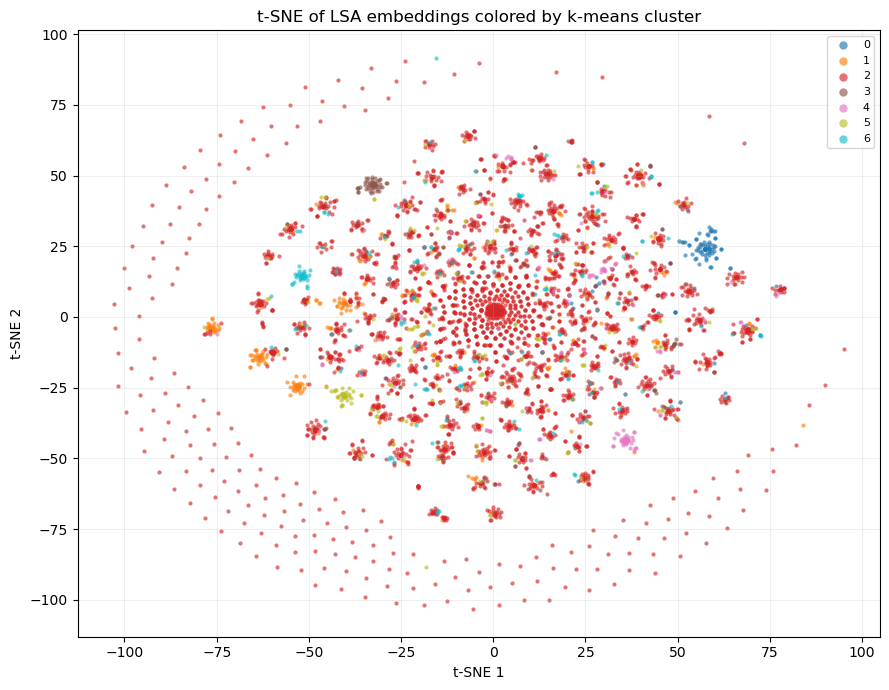

Saved ../report/figures/tsne_clusters.png


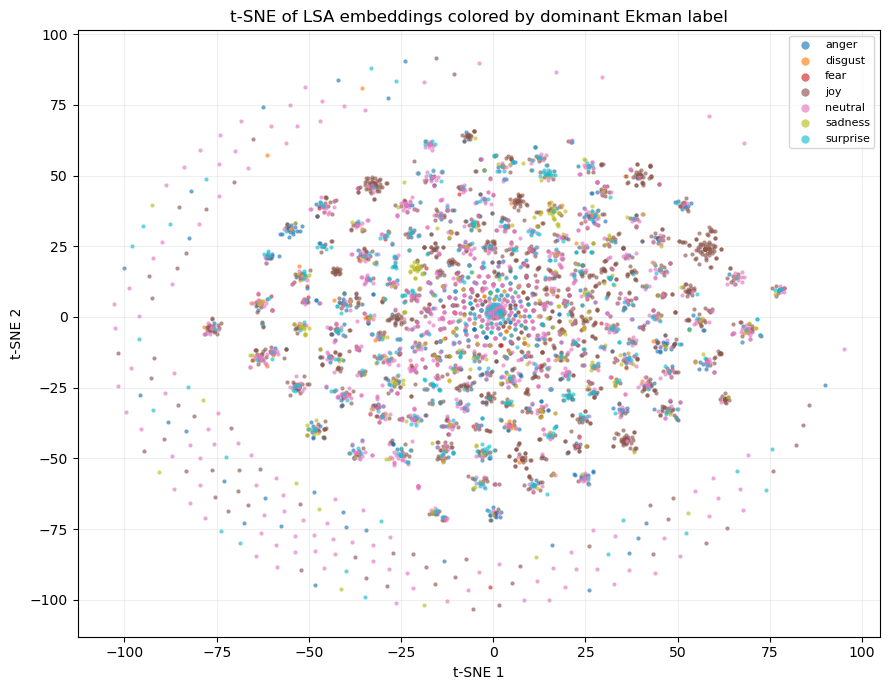

Saved ../report/figures/tsne_true_labels.png


In [22]:
# ----------------------
# t-SNE plots: clusters and true dominant labels
# ----------------------
def plot_tsne_scatter(df, color_col, title, path):
    fig, ax = plt.subplots(figsize=(9, 7))
    categories = sorted(df[color_col].unique())
    cmap = plt.get_cmap("tab10", len(categories))

    for i, category in enumerate(categories):
        mask = df[color_col] == category
        ax.scatter(
            df.loc[mask, "tsne_1"],
            df.loc[mask, "tsne_2"],
            s=9,
            alpha=0.65,
            color=cmap(i),
            label=str(category),
            linewidths=0,
        )

    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(alpha=0.2)
    ax.legend(markerscale=2, fontsize=8, frameon=True, loc="best")
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


plot_tsne_scatter(
    tsne_df,
    color_col="cluster",
    title="t-SNE of LSA embeddings colored by k-means cluster",
    path=FIGURE_DIR / "tsne_clusters.png",
)

plot_tsne_scatter(
    tsne_df,
    color_col="dominant_emotion",
    title="t-SNE of LSA embeddings colored by dominant Ekman label",
    path=FIGURE_DIR / "tsne_true_labels.png",
)


## Interpretation Notes

Use these points when writing the report:

- The clustering is unsupervised: labels are used only after fitting to interpret clusters.
- ARI/NMI may be modest because emotion detection is multi-label, while k-means assigns exactly one cluster per text.
- If the t-SNE plots show mixed colors, that is expected for short Reddit comments where emotion signals overlap and many texts are ambiguous.
- The most useful result is usually the cluster interpretation table: it shows which clusters are dominated by joy, neutral, anger, etc., and where categories blur together.
